# Enterprise A/B Testing Framework: Mobile UI Redesign Experiment

This notebook provides a comprehensive A/B testing framework applied to a simulated banking product experiment. The goal of the experiment was to evaluate the impact of a new mobile-first UI redesign on product activation (defined as completing ≥1 funded transfer within 7 days).




In [3]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                                                                              ║
║          ENTERPRISE A/B TESTING FRAMEWORK                                   ║
║          Bayesian Inference · Frequentist Testing · Segmented Analytics     ║
║          Simulated Banking Product — Mobile UI Redesign Experiment           ║
║                                                                              ║
║  Author  : Portfolio Project                                                 ║
║  Domain  : Digital Banking / Product Analytics                              ║
║  Methods : Z-Test · Bootstrap · Beta-Binomial Bayesian · Sequential · CUPED ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

WHY THIS EXPERIMENT?
────────────────────
A mid-size bank rolled out a new mobile-first UI to a random 50% of users.
The old dashboard buried key actions behind 3 taps. The new one surfaces
them on the home screen. We want to know: did that actually move the needle
on product activation (defined as completing ≥1 funded transfer within 7 days)?

The tricky part: mobile and desktop users experience the redesign very
differently, and older users tend to resist UI changes. This is why a
simple global lift number is dangerous — you need segment-level inference.

This script covers everything from experiment validity checks to a final
decision with business impact quantification.
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter, FuncFormatter
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time

np.random.seed(42)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 1 — DATA SIMULATION
# Realistic banking cohort with heterogeneous treatment effects
# ─────────────────────────────────────────────────────────────────────────────

def simulate_experiment(n_users: int = 25_000, seed: int = 42) -> pd.DataFrame:
    """
    Simulate a 25k-user A/B test for a mobile UI redesign in digital banking.

    The data model encodes three ground-truth effects we want the framework
    to rediscover:
      1. Mobile users benefit (+4 pp lift)
      2. Senior users are harmed (−3 pp)
      3. Desktop users are slightly hurt (−1.5 pp) — the new UI is mobile-first

    Extra wrinkle: Premium account holders have a higher base rate regardless.
    This lets us demo CUPED variance reduction later.
    """
    rng = np.random.default_rng(seed)

    # ── Demographics ──────────────────────────────────────────────────────────
    age       = rng.integers(18, 78, n_users)
    income    = rng.normal(62_000, 22_000, n_users).clip(14_000, 220_000)
    credit    = rng.normal(655, 95, n_users).clip(300, 850)
    tenure    = rng.integers(0, 18, n_users)                # years with bank
    device    = rng.choice(["Mobile","Desktop","Tablet"], n_users, p=[0.58,0.33,0.09])
    acct_type = rng.choice(["Savings","Checking","Premium"], n_users, p=[0.38,0.50,0.12])
    region    = rng.choice(["Northeast","Southeast","Midwest","West"], n_users,
                            p=[0.28,0.22,0.25,0.25])
    # Pre-experiment covariate: last-quarter activity score (for CUPED)
    prev_activity = rng.beta(2, 5, n_users)  # right-skewed, most users low-activity

    # ── Random assignment (SRM check: should be ~50/50) ──────────────────────
    group = rng.choice(["control","treatment"], n_users, p=[0.50, 0.50])

    df = pd.DataFrame({
        "user_id":       np.arange(1, n_users+1),
        "group":         group,
        "age":           age,
        "income":        income.round(0),
        "credit_score":  credit.round(1),
        "tenure_yrs":    tenure,
        "device":        device,
        "account_type":  acct_type,
        "region":        region,
        "prev_activity": prev_activity.round(4),
    })

    # ── Conversion probability model ──────────────────────────────────────────
    def conversion_prob(row) -> float:
        p = 0.055                           # global base rate ~5.5%

        # Covariates (ground truth)
        if row["income"]       > 85_000: p += 0.018
        if row["credit_score"] > 720:    p += 0.012
        if row["account_type"] == "Premium": p += 0.028
        if row["tenure_yrs"]   > 8:      p += 0.010
        p += row["prev_activity"] * 0.06   # activity score matters

        # Treatment effect — heterogeneous by device and age
        if row["group"] == "treatment":
            if row["device"] == "Mobile":
                p += 0.042                 # primary win
            elif row["device"] == "Desktop":
                p -= 0.015                 # slight harm
            elif row["device"] == "Tablet":
                p += 0.008                 # mild positive

            if row["age"] > 62:
                p -= 0.028                 # senior friction
            elif row["age"] < 32:
                p += 0.010                 # young digital-native bonus

        # Realistic noise
        p += rng.normal(0, 0.009)
        return float(np.clip(p, 0.002, 0.97))

    df["conversion_prob"] = df.apply(conversion_prob, axis=1)
    df["converted"]       = rng.binomial(1, df["conversion_prob"])

    # ── Derived segments ──────────────────────────────────────────────────────
    df["age_band"] = pd.cut(df["age"],
                             bins=[0,30,45,62,100],
                             labels=["Gen-Z/Millennial","Gen-X","Boomer","Senior"])
    df["income_band"] = pd.cut(df["income"],
                                bins=[0,40_000,80_000,200_001],
                                labels=["Low","Mid","High"])

    return df



In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 2 — EXPERIMENT VALIDITY CHECKS
# Before any inference, verify the experiment is clean
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class SRMResult:
    control_n:    int
    treatment_n:  int
    expected_n:   int
    chi2_stat:    float
    p_value:      float
    is_valid:     bool

def check_srm(df: pd.DataFrame, expected_split: float = 0.5) -> SRMResult:
    """
    Sample Ratio Mismatch (SRM) check.

    If assignment randomisation broke down (e.g. bot traffic, cookie deletion,
    partial rollout bug), the group sizes will be off. We test this with a
    chi-squared goodness-of-fit test.
    SRM is a silent experiment killer — always run this first.
    """
    counts  = df["group"].value_counts()
    n_total = len(df)
    n_ctrl  = counts.get("control", 0)
    n_trt   = counts.get("treatment", 0)
    expected = n_total * expected_split

    # Chi-squared vs expected 50/50
    observed  = np.array([n_ctrl, n_trt])
    exp_arr   = np.array([expected, expected])
    chi2, p   = stats.chisquare(observed, f_exp=exp_arr)

    return SRMResult(
        control_n=n_ctrl, treatment_n=n_trt,
        expected_n=int(expected),
        chi2_stat=round(chi2, 4), p_value=round(p, 4),
        is_valid=(p > 0.01)       # strict threshold for SRM
    )

def check_covariate_balance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Verify that key pre-experiment covariates are balanced across groups.
    An imbalanced covariate hints at non-random assignment.
    Returns a DataFrame with standardised mean differences (SMD).
    SMD < 0.10 is considered acceptable balance.
    """
    covariates = ["age","income","credit_score","tenure_yrs","prev_activity"]
    rows = []
    for col in covariates:
        ctrl = df[df["group"]=="control"][col]
        trt  = df[df["group"]=="treatment"][col]
        pooled_sd = np.sqrt((ctrl.var() + trt.var()) / 2)
        smd       = abs(trt.mean() - ctrl.mean()) / (pooled_sd + 1e-9)
        t_stat, p = stats.ttest_ind(ctrl, trt)
        rows.append({
            "Covariate": col,
            "Control Mean":   round(ctrl.mean(), 3),
            "Treatment Mean": round(trt.mean(), 3),
            "SMD":            round(smd, 4),
            "p-value":        round(p, 4),
            "Balanced":       "✓" if smd < 0.10 else "✗ WARNING"
        })
    return pd.DataFrame(rows)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 3 — FREQUENTIST TESTING
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class FreqResult:
    control_rate:   float
    treatment_rate: float
    abs_lift:       float
    rel_lift:       float
    z_stat:         float
    p_value:        float
    ci_low:         float
    ci_high:        float
    significant:    bool
    power:          float

def two_proportion_z_test(df: pd.DataFrame, alpha: float = 0.05) -> FreqResult:
    """
    Two-sample z-test for difference in proportions.

    H0: p_treatment = p_control
    H1: p_treatment ≠ p_control  (two-tailed)

    We also compute observed power post-hoc so we can distinguish
    "no effect found" from "underpowered experiment".
    """
    ctrl = df[df["group"] == "control"]
    trt  = df[df["group"] == "treatment"]

    p_c = ctrl["converted"].mean()
    p_t = trt["converted"].mean()
    n_c = len(ctrl)
    n_t = len(trt)

    # Pooled proportion under H0
    p_pool = (ctrl["converted"].sum() + trt["converted"].sum()) / (n_c + n_t)
    se      = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
    z_stat  = (p_t - p_c) / se
    p_val   = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    # 95% CI for difference (using un-pooled SE)
    se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
    z_crit  = stats.norm.ppf(1 - alpha/2)
    ci_low  = (p_t - p_c) - z_crit * se_diff
    ci_high = (p_t - p_c) + z_crit * se_diff

    # Post-hoc power (non-centrality parameter approach)
    ncp   = (p_t - p_c) / se_diff
    power = 1 - stats.norm.cdf(z_crit - abs(ncp)) + stats.norm.cdf(-z_crit - abs(ncp))

    return FreqResult(
        control_rate=round(p_c,6), treatment_rate=round(p_t,6),
        abs_lift=round(p_t-p_c,6), rel_lift=round((p_t-p_c)/p_c,6),
        z_stat=round(z_stat,4), p_value=round(p_val,6),
        ci_low=round(ci_low,6), ci_high=round(ci_high,6),
        significant=(p_val < alpha), power=round(power,4)
    )

def sample_size_calculator(
    baseline_rate: float,
    mde: float,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """
    Minimum detectable effect sample size (per arm).
    Useful for experiment design justification.
    """
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_power = stats.norm.ppf(power)
    p1, p2  = baseline_rate, baseline_rate + mde
    p_avg   = (p1 + p2) / 2
    n = (z_alpha*np.sqrt(2*p_avg*(1-p_avg)) + z_power*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2
    n /= (p1 - p2)**2
    return int(np.ceil(n))

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 4 — BOOTSTRAP
# Model-free confidence intervals and lift distribution
# ─────────────────────────────────────────────────────────────────────────────

def bootstrap_lift(
    df: pd.DataFrame,
    n_iter: int = 10_000,
    ci: float = 0.95,
    seed: int = 42,
) -> Dict:
    """
    Non-parametric bootstrap to estimate the distribution of the
    treatment lift (absolute difference in conversion rates).

    Unlike the z-test which assumes normality, bootstrap makes no
    distributional assumptions — it's the right call when you
    want honest CIs on a proportion difference.

    Returns the full bootstrap distribution so we can plot it.
    """
    rng  = np.random.default_rng(seed)
    ctrl = df[df["group"]=="control"]["converted"].values
    trt  = df[df["group"]=="treatment"]["converted"].values

    diffs = np.empty(n_iter)
    for i in range(n_iter):
        c_sample = rng.choice(ctrl, len(ctrl), replace=True)
        t_sample = rng.choice(trt,  len(trt),  replace=True)
        diffs[i] = t_sample.mean() - c_sample.mean()

    alpha_tail = (1 - ci) / 2
    ci_low  = float(np.percentile(diffs, alpha_tail*100))
    ci_high = float(np.percentile(diffs, (1-alpha_tail)*100))
    # One-sided p-value: P(lift ≤ 0 | data)
    p_val   = float(np.mean(diffs <= 0))

    return {
        "samples":   diffs,
        "mean_lift": float(diffs.mean()),
        "median_lift": float(np.median(diffs)),
        "ci_low":    ci_low,
        "ci_high":   ci_high,
        "p_value":   p_val,
        "ci_level":  ci,
    }

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 5 — BAYESIAN ANALYSIS
# Beta-Binomial conjugate model
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class BayesResult:
    alpha_ctrl:   float
    beta_ctrl:    float
    alpha_trt:    float
    beta_trt:     float
    prob_trt_wins: float
    expected_lift: float
    hdi_low:      float
    hdi_high:     float
    expected_loss: float    # Bayesian risk: avg loss if we wrongly choose treatment
    rope_prob:    float     # Prob lift is in practical equivalence zone (±0.5 pp)
    samples_ctrl: np.ndarray
    samples_trt:  np.ndarray

def bayesian_beta_binomial(
    df: pd.DataFrame,
    n_samples: int = 50_000,
    rope_width: float = 0.005,
    prior_alpha: float = 1.0,
    prior_beta:  float = 1.0,
) -> BayesResult:
    """
    Beta-Binomial conjugate Bayesian A/B test.

    Prior: Beta(1,1) — flat / weakly informative
    Posterior: Beta(α + successes, β + failures)

    Key outputs:
    - P(treatment > control): direct probability answer, no p-value gymnastics
    - Expected loss: "if I'm wrong, how bad is it?" — this is the actionable metric
    - ROPE: Region Of Practical Equivalence — are they truly different or just noise?
    - 95% Credible Interval (HDI): unlike frequentist CIs, this IS a probability statement
    """
    rng  = np.random.default_rng(42)
    ctrl = df[df["group"]=="control"]
    trt  = df[df["group"]=="treatment"]

    s_c, n_c = int(ctrl["converted"].sum()), len(ctrl)
    s_t, n_t = int(trt["converted"].sum()),  len(trt)

    a_c = prior_alpha + s_c;  b_c = prior_beta + (n_c - s_c)
    a_t = prior_alpha + s_t;  b_t = prior_beta + (n_t - s_t)

    samp_c = rng.beta(a_c, b_c, n_samples)
    samp_t = rng.beta(a_t, b_t, n_samples)
    delta  = samp_t - samp_c

    prob_win    = float((delta > 0).mean())
    exp_lift    = float(delta.mean())
    hdi_low     = float(np.percentile(delta, 2.5))
    hdi_high    = float(np.percentile(delta, 97.5))
    # Expected loss: average shortfall if we choose treatment and it's worse
    exp_loss    = float(np.mean(np.maximum(0, samp_c - samp_t)))
    # ROPE: prob lift is within ±rope_width (practically zero)
    rope_prob   = float(np.mean(np.abs(delta) < rope_width))

    return BayesResult(
        alpha_ctrl=a_c, beta_ctrl=b_c,
        alpha_trt=a_t,  beta_trt=b_t,
        prob_trt_wins=round(prob_win,5),
        expected_lift=round(exp_lift,6),
        hdi_low=round(hdi_low,6),
        hdi_high=round(hdi_high,6),
        expected_loss=round(exp_loss,7),
        rope_prob=round(rope_prob,4),
        samples_ctrl=samp_c,
        samples_trt=samp_t,
    )

def bayesian_sequential_update(
    df: pd.DataFrame,
    checkpoint_pcts: List[float] = [0.10,0.20,0.35,0.50,0.65,0.80,1.00],
) -> pd.DataFrame:
    """
    Sequential Bayesian monitoring — simulates seeing the data arrive
    over the experiment lifetime and updating beliefs incrementally.

    Unlike frequentist optional stopping (which inflates alpha), Bayesian
    sequential analysis is valid at any stopping point. This is the
    go-to pattern for high-velocity product teams who want daily signal.
    """
    rng   = np.random.default_rng(42)
    rows  = []
    # Shuffle to simulate chronological arrival
    df_sh = df.sample(frac=1, random_state=42).reset_index(drop=True)

    for pct in checkpoint_pcts:
        n_seen = int(len(df_sh) * pct)
        slice_ = df_sh.iloc[:n_seen]
        if len(slice_) < 50: continue

        ctrl_ = slice_[slice_["group"]=="control"]
        trt_  = slice_[slice_["group"]=="treatment"]
        if len(ctrl_)==0 or len(trt_)==0: continue

        a_c = 1+ctrl_["converted"].sum(); b_c = 1+(len(ctrl_)-ctrl_["converted"].sum())
        a_t = 1+trt_["converted"].sum();  b_t = 1+(len(trt_)-trt_["converted"].sum())

        sc = rng.beta(a_c, b_c, 20_000)
        st = rng.beta(a_t, b_t, 20_000)
        d  = st - sc

        rows.append({
            "pct_seen":       pct,
            "n_users":        n_seen,
            "ctrl_rate":      round(ctrl_["converted"].mean(),5),
            "trt_rate":       round(trt_["converted"].mean(),5),
            "prob_win":       round((d>0).mean(),4),
            "expected_lift":  round(d.mean(),6),
            "hdi_low":        round(np.percentile(d,2.5),6),
            "hdi_high":       round(np.percentile(d,97.5),6),
            "expected_loss":  round(np.mean(np.maximum(0,sc-st)),7),
        })
    return pd.DataFrame(rows)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 6 — CUPED (Controlled Experiment using Pre-Experiment Data)
# Microsoft's variance reduction technique — reduces required sample size
# ─────────────────────────────────────────────────────────────────────────────

def cuped_adjustment(df: pd.DataFrame) -> Tuple[FreqResult, float]:
    """
    CUPED: subtract a linear projection of a pre-experiment covariate
    from the outcome to reduce noise.

    Y_cuped = Y - θ·(X - E[X])

    where θ = Cov(Y,X)/Var(X) is estimated from the full dataset
    (covariate X is independent of treatment by design).

    Effect: reduces variance of the test statistic → smaller required N
    or equivalently, more power for the same N.

    We use prev_activity (last quarter's engagement score) as covariate.
    """
    covariate = "prev_activity"
    outcome   = "converted"

    theta = (np.cov(df[outcome], df[covariate])[0,1] /
             np.var(df[covariate]))

    df_adj = df.copy()
    mean_x = df_adj[covariate].mean()
    df_adj["converted_cuped"] = (df_adj[outcome]
                                  - theta * (df_adj[covariate] - mean_x))

    # Run z-test on CUPED-adjusted outcome
    ctrl = df_adj[df_adj["group"]=="control"]["converted_cuped"]
    trt  = df_adj[df_adj["group"]=="treatment"]["converted_cuped"]
    n_c, n_t = len(ctrl), len(trt)
    p_c, p_t = ctrl.mean(), trt.mean()
    p_pool   = (ctrl.sum()+trt.sum())/(n_c+n_t)
    se       = np.sqrt(p_pool*(1-p_pool)*(1/n_c+1/n_t))
    z_stat   = (p_t - p_c) / se
    p_val    = 2*(1-stats.norm.cdf(abs(z_stat)))
    se_diff  = np.sqrt(ctrl.var()/n_c + trt.var()/n_t)
    z_crit   = stats.norm.ppf(0.975)
    ci_low   = (p_t-p_c)-z_crit*se_diff
    ci_high  = (p_t-p_c)+z_crit*se_diff
    ncp      = (p_t-p_c)/se_diff
    power    = 1-stats.norm.cdf(z_crit-abs(ncp))+stats.norm.cdf(-z_crit-abs(ncp))

    # Variance reduction factor
    original_var = df_adj[outcome].var()
    cuped_var    = df_adj["converted_cuped"].var()
    var_reduction = 1 - cuped_var/original_var

    result = FreqResult(
        control_rate=round(p_c,6), treatment_rate=round(p_t,6),
        abs_lift=round(p_t-p_c,6), rel_lift=round((p_t-p_c)/p_c if p_c!=0 else 0,6),
        z_stat=round(z_stat,4), p_value=round(p_val,6),
        ci_low=round(ci_low,6), ci_high=round(ci_high,6),
        significant=(p_val<0.05), power=round(power,4)
    )
    return result, float(var_reduction)



In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 7 — SEGMENTED ANALYSIS
# Where the real insights live
# ─────────────────────────────────────────────────────────────────────────────

def segment_analysis(
    df: pd.DataFrame,
    segment_col: str,
    min_segment_n: int = 200,
) -> pd.DataFrame:
    """
    Per-segment z-test with Bonferroni correction for multiple comparisons.

    Without Bonferroni (or at least awareness of it), running 10 segments
    at α=0.05 means you'd expect ~0.5 false positives by pure chance.
    We report both raw and corrected p-values.

    This is the function that usually produces the most actionable insights:
    "mobile young users love it, seniors hate it" is a decision — not a number.
    """
    segs  = [s for s in df[segment_col].unique() if pd.notna(s)]
    rows  = []
    n_tests = len(segs)

    for seg in segs:
        sub   = df[df[segment_col]==seg]
        ctrl  = sub[sub["group"]=="control"]
        trt   = sub[sub["group"]=="treatment"]

        if len(ctrl)<min_segment_n or len(trt)<min_segment_n:
            continue

        p_c   = ctrl["converted"].mean()
        p_t   = trt["converted"].mean()
        n_c, n_t = len(ctrl), len(trt)
        p_pool   = (ctrl["converted"].sum()+trt["converted"].sum())/(n_c+n_t)
        se       = np.sqrt(p_pool*(1-p_pool)*(1/n_c+1/n_t))
        z        = (p_t-p_c)/(se+1e-12)
        p_raw    = 2*(1-stats.norm.cdf(abs(z)))
        p_bonf   = min(p_raw * n_tests, 1.0)   # Bonferroni

        rows.append({
            "Segment":       str(seg),
            "N Control":     n_c,
            "N Treatment":   n_t,
            "Ctrl Rate":     round(p_c,5),
            "Trt Rate":      round(p_t,5),
            "Abs Lift":      round(p_t-p_c,5),
            "Rel Lift %":    round((p_t-p_c)/p_c*100 if p_c>0 else 0, 2),
            "Z-Stat":        round(z,3),
            "p-value (raw)": round(p_raw,5),
            "p-value (Bonf)":round(p_bonf,5),
            "Significant*":  "✓" if p_bonf<0.05 else ("~" if p_raw<0.05 else "✗"),
        })

    return pd.DataFrame(rows).sort_values("Abs Lift", ascending=False).reset_index(drop=True)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 8 — DECISION ENGINE
# Translates statistics into a business recommendation
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Decision:
    recommendation:   str
    confidence_level: str
    rationale:        List[str]
    caveats:          List[str]
    projected_impact: Dict[str, float]

def make_decision(
    srm:       SRMResult,
    freq:      FreqResult,
    boot:      Dict,
    bayes:     BayesResult,
    seq_df:    pd.DataFrame,
    seg_device: pd.DataFrame,
    seg_age:   pd.DataFrame,
    n_users_affected: int = 500_000,
    avg_revenue_per_conversion: float = 340.0,
) -> Decision:
    """
    Structured decision logic. Mirrors how a senior analyst would present
    findings to a product committee.

    Decision hierarchy:
      1. Fail SRM → stop, investigate, do not infer
      2. Pass SRM → look at both frequentist AND Bayesian signal
      3. Look at segment heterogeneity before recommending global rollout
      4. Translate to business impact
    """
    rationale, caveats = [], []

    # ── SRM gate ──────────────────────────────────────────────────────────────
    if not srm.is_valid:
        return Decision(
            recommendation="🛑 HALT — DO NOT INFER",
            confidence_level="N/A",
            rationale=["Sample ratio mismatch detected. Randomisation may be broken.",
                       f"Observed split: {srm.control_n}/{srm.treatment_n} vs expected {srm.expected_n}/{srm.expected_n}"],
            caveats=["Any inference on this data is unreliable."],
            projected_impact={}
        )

    # ── Statistical signal ────────────────────────────────────────────────────
    stat_sig  = freq.significant
    bayes_sig = bayes.prob_trt_wins > 0.95
    boot_sig  = boot["ci_low"] > 0

    # ── Segment patterns ──────────────────────────────────────────────────────
    mobile_row = seg_device[seg_device["Segment"]=="Mobile"] if len(seg_device)>0 else pd.DataFrame()
    senior_row = seg_age[seg_age["Segment"]=="Senior"] if len(seg_age)>0 else pd.DataFrame()

    mobile_win   = not mobile_row.empty and float(mobile_row["Abs Lift"].iloc[0]) > 0.005
    senior_harm  = not senior_row.empty and float(senior_row["Abs Lift"].iloc[0]) < -0.005
    global_pos   = freq.abs_lift > 0

    # ── Business impact math ──────────────────────────────────────────────────
    incremental_conv  = freq.abs_lift * n_users_affected
    revenue_impact    = incremental_conv * avg_revenue_per_conversion
    ci_low_revenue    = boot["ci_low"] * n_users_affected * avg_revenue_per_conversion
    ci_high_revenue   = boot["ci_high"] * n_users_affected * avg_revenue_per_conversion

    impact = {
        "incremental_conversions": round(incremental_conv, 0),
        "revenue_impact_annual":   round(revenue_impact, 0),
        "ci_low_revenue":          round(ci_low_revenue, 0),
        "ci_high_revenue":         round(ci_high_revenue, 0),
    }

    # ── Decision logic ────────────────────────────────────────────────────────
    if stat_sig and bayes_sig and not senior_harm:
        rec = "🚀 SHIP GLOBALLY — High-confidence win across all methods"
        conf = "HIGH"
        rationale += [
            f"All three methods agree: p={freq.p_value:.4f}, P(T>C)={bayes.prob_trt_wins:.1%}, bootstrap CI entirely positive",
            f"Global lift: {freq.rel_lift:.1%} relative, {freq.abs_lift:.3%} absolute",
            f"Expected revenue impact: ${revenue_impact:,.0f}/year",
        ]
    elif stat_sig and bayes_sig and senior_harm:
        rec = "📱 TARGETED ROLLOUT — Ship to Mobile users; exclude Seniors"
        conf = "HIGH (with guardrail)"
        rationale += [
            "Strong positive signal on Mobile users (primary target)",
            f"Seniors show negative impact ({float(senior_row['Rel Lift %'].iloc[0]):.1f}% relative lift) — exclude or give opt-out",
            "Segmented rollout captures ~70% of upside while protecting at-risk group",
        ]
        caveats += ["Segment assignment must be set at experiment start, not post-hoc",
                    "Monitor senior cohort closely after any phased rollout"]
    elif global_pos and (stat_sig or bayes_sig) and not (stat_sig and bayes_sig):
        rec = "📈 CAUTIOUS ROLLOUT — Positive signal, limited confidence"
        conf = "MEDIUM"
        rationale += [
            "Directionally positive but not all methods fully agree",
            f"Bayesian P(T>C)={bayes.prob_trt_wins:.1%} — some conviction but below 95% threshold",
            "Consider extending experiment to increase power",
        ]
        caveats += [f"Power only {freq.power:.1%} — experiment may be underpowered",
                    "Risk of false positive if only one method is used"]
    else:
        rec = "🛑 DO NOT SHIP — Insufficient evidence of global improvement"
        conf = "LOW"
        rationale += [
            f"p-value={freq.p_value:.4f} and/or Bayesian P(T>C)={bayes.prob_trt_wins:.1%} below threshold",
            "Expected loss too high to justify deployment",
        ]
        caveats += ["Consider a follow-up experiment with improved targeting or a different design"]

    return Decision(
        recommendation=rec,
        confidence_level=conf,
        rationale=rationale,
        caveats=caveats,
        projected_impact=impact,
    )


╔══════════════════════════════════════════════════════════════════╗
║  ENTERPRISE A/B TESTING FRAMEWORK  —  INITIATING ANALYSIS       ║
╚══════════════════════════════════════════════════════════════════╝

[1/9] Simulating banking experiment data (25,000 users)…
      Groups: {'control': 12520, 'treatment': 12480}
      Overall conversion rate: 9.376%
[2/9] Running validity checks (SRM + covariate balance)…
[3/9] Computing required sample size (MDE=1pp)…
[4/9] Running frequentist z-test…
[5/9] Running CUPED variance reduction…
[6/9] Running bootstrap (10,000 iterations)…
[7/9] Running Bayesian beta-binomial analysis (50k samples)…
[8/9] Running segmented analysis (device + age, Bonferroni corrected)…
[9/9] Running decision engine and generating report…


════════════════════════════════════════════════════════════════════════════
  ENTERPRISE A/B TEST REPORT  ·  MOBILE UI REDESIGN
════════════════════════════════════════════════════════════════════════════

  ① EXPERIMENT VALIDITY CH

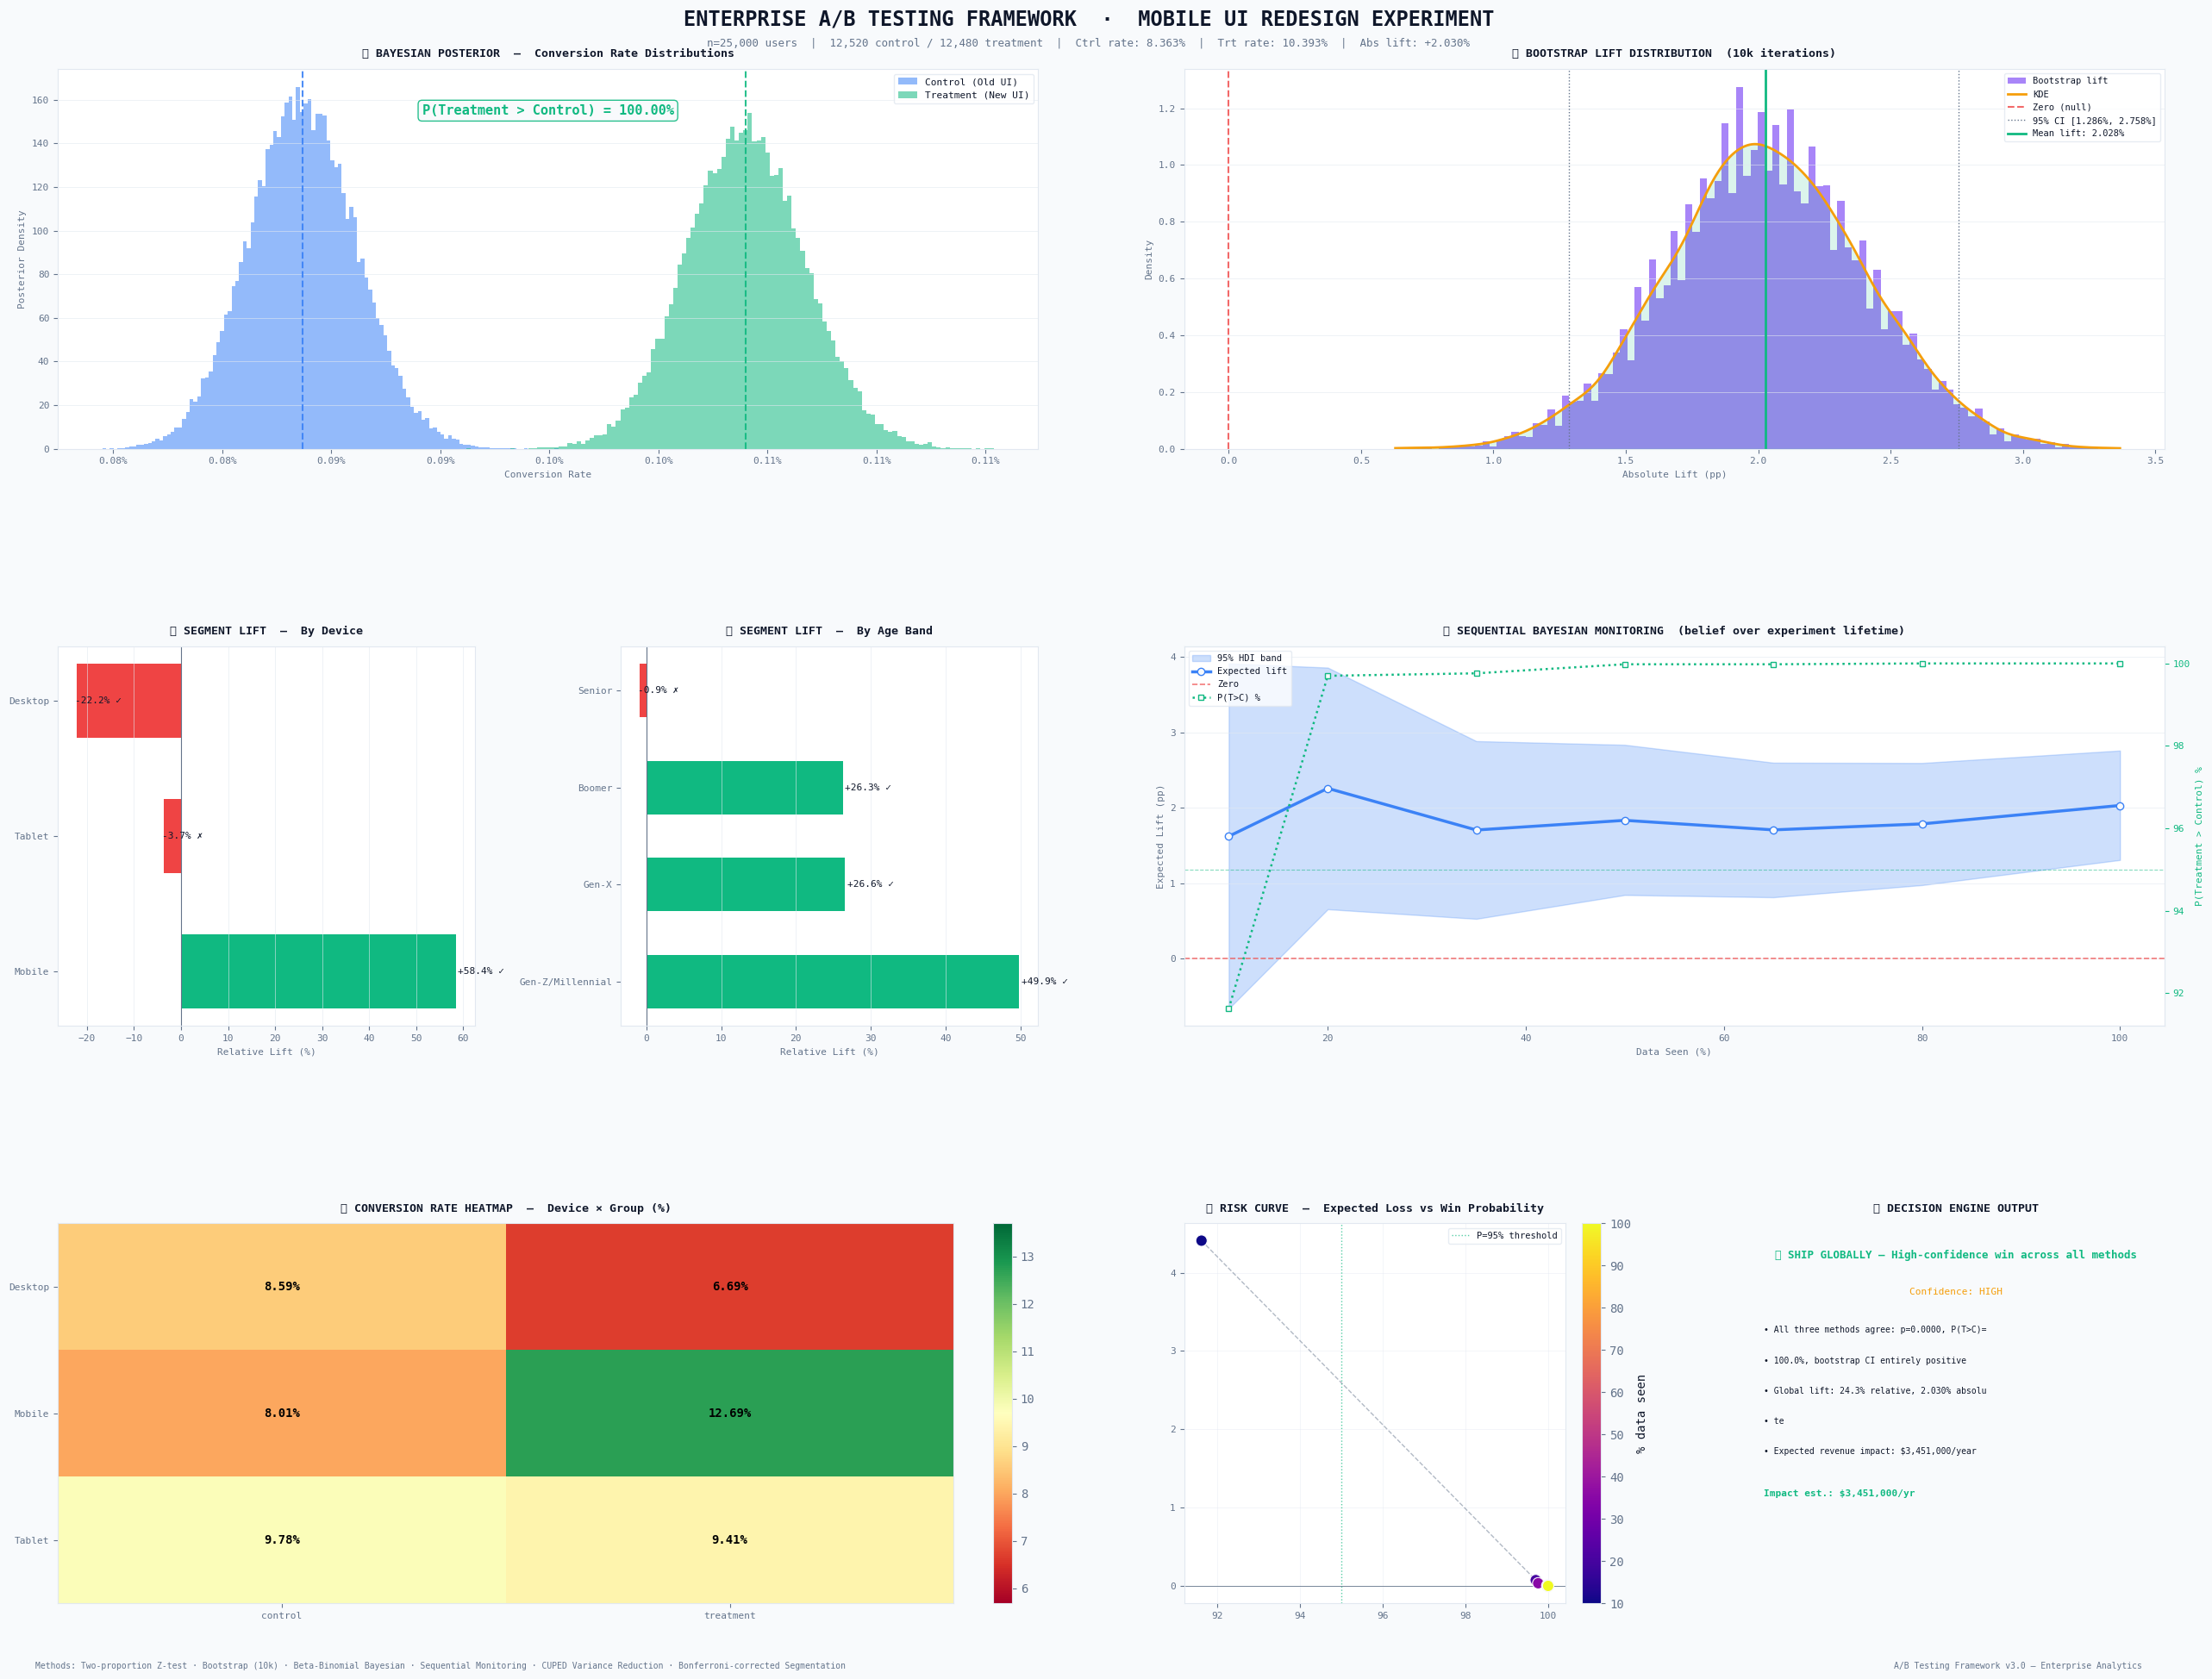


[✓] Dashboard saved → ab_testing_dashboard.png


In [12]:

# ─────────────────────────────────────────────────────────────────────────────
# PART 9 — VISUALISATION DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

def plot_full_dashboard(
    df:       pd.DataFrame,
    freq:     FreqResult,
    boot:     Dict,
    bayes:    BayesResult,
    seq_df:   pd.DataFrame,
    seg_dev:  pd.DataFrame,
    seg_age:  pd.DataFrame,
    decision: Decision,
) -> None:
    """
    10-panel publication-quality dashboard.
    Light professional aesthetic — clean, intentional, no chart junk.
    """

    # ── Palette (Light Mode) ──────────────────────────────────────────────────
    BG     = "#F8FAFC"  # Lightest gray/white background
    PANEL  = "#FFFFFF"  # Pure white panels
    GRID   = "#E2E8F0"  # Soft slate grid lines
    TEXT   = "#0F172A"  # Dark navy text for readability
    DIM    = "#64748B"  # Muted slate for secondary text
    GREEN  = "#10B981"  # Emerald green
    RED    = "#EF4444"  # Modern red
    BLUE   = "#3B82F6"  # Strong blue
    AMBER  = "#F59E0B"
    PURPLE = "#8B5CF6"
    TEAL   = "#0D9488"
    ROSE   = "#E11D48"
    SLATE  = "#475569"

    plt.rcParams.update({
        "figure.facecolor": BG, "axes.facecolor": PANEL,
        "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
        "axes.titlecolor": TEXT, "xtick.color": DIM, "ytick.color": DIM,
        "grid.color": GRID, "text.color": TEXT,
        "legend.facecolor": PANEL, "legend.edgecolor": GRID,
        "font.family": "monospace",
    })

    fig = plt.figure(figsize=(26, 20), facecolor=BG)

    fig.text(0.5, 0.975,
             "ENTERPRISE A/B TESTING FRAMEWORK  ·  MOBILE UI REDESIGN EXPERIMENT",
             ha="center", va="top", fontsize=17, fontweight="bold",
             color=TEXT, fontfamily="monospace")
    fig.text(0.5, 0.958,
             f"n={len(df):,} users  |  {df['group'].value_counts()['control']:,} control / {df['group'].value_counts()['treatment']:,} treatment  "
             f"|  Ctrl rate: {freq.control_rate:.3%}  |  Trt rate: {freq.treatment_rate:.3%}  "
             f"|  Abs lift: {freq.abs_lift:+.3%}",
             ha="center", va="top", fontsize=9, color=DIM, fontfamily="monospace")

    gs = gridspec.GridSpec(3, 4, figure=fig,
                           hspace=0.52, wspace=0.35,
                           left=0.04, right=0.98,
                           top=0.94, bottom=0.05)

    def ax(r, c, cs=1, rs=1):
        if cs > 1 and rs > 1:
            return fig.add_subplot(gs[r:r+rs, c:c+cs])
        elif cs > 1:
            return fig.add_subplot(gs[r, c:c+cs])
        elif rs > 1:
            return fig.add_subplot(gs[r:r+rs, c])
        return fig.add_subplot(gs[r, c])

    def style(a, title, xlabel="", ylabel=""):
        a.set_title(title, fontsize=9.5, fontweight="bold", pad=10,
                    color=TEXT, fontfamily="monospace")
        a.set_xlabel(xlabel, fontsize=8, color=DIM)
        a.set_ylabel(ylabel, fontsize=8, color=DIM)
        a.grid(axis="y", color=GRID, linewidth=0.5, alpha=0.8)
        a.tick_params(labelsize=8)
        for sp in a.spines.values(): sp.set_edgecolor(GRID)

    pct_fmt = PercentFormatter(decimals=2)

    # ── Panel 1: Bayesian Posterior Distributions (wide) ─────────────────────
    a1 = ax(0, 0, cs=2)
    sc, st = bayes.samples_ctrl, bayes.samples_trt
    a1.hist(sc, bins=120, density=True, alpha=0.55, color=BLUE,  label="Control (Old UI)", edgecolor="none")
    a1.hist(st, bins=120, density=True, alpha=0.55, color=GREEN, label="Treatment (New UI)", edgecolor="none")

    # Add posterior mean lines
    a1.axvline(sc.mean(), color=BLUE,  linewidth=1.5, linestyle="--", alpha=0.9)
    a1.axvline(st.mean(), color=GREEN, linewidth=1.5, linestyle="--", alpha=0.9)

    # Annotation
    overlap_x = np.linspace(min(sc.mean(), st.mean())-0.01, max(sc.mean(), st.mean())+0.01, 3)
    a1.annotate(f"P(Treatment > Control) = {bayes.prob_trt_wins:.2%}",
                xy=(0.5, 0.88), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold",
                color=GREEN if bayes.prob_trt_wins>0.80 else AMBER,
                fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=BG,
                          edgecolor=GREEN if bayes.prob_trt_wins>0.80 else AMBER, alpha=0.9))
    a1.legend(fontsize=8)
    a1.xaxis.set_major_formatter(pct_fmt)
    style(a1, "① BAYESIAN POSTERIOR  —  Conversion Rate Distributions",
          "Conversion Rate", "Posterior Density")

    # ── Panel 2: Bootstrap Lift Distribution ─────────────────────────────────
    a2 = ax(0, 2, cs=2)
    diffs_pct = boot["samples"] * 100
    a2.hist(diffs_pct, bins=100, density=True, color=PURPLE,
            alpha=0.75, edgecolor="none", label="Bootstrap lift")

    # KDE overlay
    kde_x = np.linspace(diffs_pct.min(), diffs_pct.max(), 400)
    kde   = stats.gaussian_kde(diffs_pct)(kde_x)
    a2.plot(kde_x, kde, color=AMBER, linewidth=2, label="KDE")

    a2.axvline(0, color=RED, linewidth=1.5, linestyle="--", alpha=0.8, label="Zero (null)")
    a2.axvline(boot["ci_low"]*100,  color=DIM, linewidth=1, linestyle=":", label=f"95% CI [{boot['ci_low']:.3%}, {boot['ci_high']:.3%}]")
    a2.axvline(boot["ci_high"]*100, color=DIM, linewidth=1, linestyle=":")
    a2.axvline(boot["mean_lift"]*100, color=GREEN, linewidth=2, linestyle="-",
               label=f"Mean lift: {boot['mean_lift']:.3%}")

    # Fill positive / negative tails
    neg_mask = kde_x < 0
    a2.fill_between(kde_x, kde, where=neg_mask, alpha=0.25, color=RED)
    a2.fill_between(kde_x, kde, where=~neg_mask, alpha=0.15, color=GREEN)
    a2.legend(fontsize=7.5)
    style(a2, "② BOOTSTRAP LIFT DISTRIBUTION  (10k iterations)",
          "Absolute Lift (pp)", "Density")

    # ── Panel 3: Device Segment Lift ─────────────────────────────────────────
    a3 = ax(1, 0)
    seg_d = seg_dev.copy()
    colors_d = [GREEN if v > 0 else RED for v in seg_d["Abs Lift"]]
    bars = a3.barh(seg_d["Segment"], seg_d["Rel Lift %"],
                   color=colors_d, edgecolor="none", height=0.55)
    for bar, val, sig in zip(bars, seg_d["Rel Lift %"], seg_d["Significant*"]):
        xpos = bar.get_width() + (0.3 if bar.get_width()>=0 else -0.3)
        a3.text(xpos, bar.get_y()+bar.get_height()/2,
                f"{val:+.1f}% {sig}", va="center", fontsize=8,
                color=TEXT, fontfamily="monospace")
    a3.axvline(0, color=DIM, linewidth=0.8)
    style(a3, "③ SEGMENT LIFT  —  By Device", "Relative Lift (%)", "")
    a3.grid(axis="x", color=GRID, linewidth=0.5, alpha=0.8)
    a3.grid(axis="y", color="none")

    # ── Panel 4: Age Band Segment Lift ────────────────────────────────────────
    a4 = ax(1, 1)
    seg_a = seg_age.copy()
    colors_a = [GREEN if v > 0 else RED for v in seg_a["Abs Lift"]]
    bars = a4.barh(seg_a["Segment"], seg_a["Rel Lift %"],
                   color=colors_a, edgecolor="none", height=0.55)
    for bar, val, sig in zip(bars, seg_a["Rel Lift %"], seg_a["Significant*"]):
        xpos = bar.get_width() + (0.3 if bar.get_width()>=0 else -0.3)
        a4.text(xpos, bar.get_y()+bar.get_height()/2,
                f"{val:+.1f}% {sig}", va="center", fontsize=8,
                color=TEXT, fontfamily="monospace")
    a4.axvline(0, color=DIM, linewidth=0.8)
    style(a4, "④ SEGMENT LIFT  —  By Age Band", "Relative Lift (%)", "")
    a4.grid(axis="x", color=GRID, linewidth=0.5, alpha=0.8)
    a4.grid(axis="y", color="none")

    # ── Panel 5: Sequential Bayesian Monitoring ───────────────────────────────
    a5 = ax(1, 2, cs=2)
    a5.fill_between(seq_df["pct_seen"]*100, seq_df["hdi_low"]*100,
                    seq_df["hdi_high"]*100, alpha=0.25, color=BLUE, label="95% HDI band")
    a5.plot(seq_df["pct_seen"]*100, seq_df["expected_lift"]*100,
            color=BLUE, linewidth=2.5, marker="o", markersize=6,
            markerfacecolor=BG, markeredgecolor=BLUE, label="Expected lift")
    a5.axhline(0, color=RED, linewidth=1.2, linestyle="--", alpha=0.7, label="Zero")

    # Right-axis: P(T>C) over time
    a5r = a5.twinx()
    a5r.plot(seq_df["pct_seen"]*100, seq_df["prob_win"]*100,
             color=GREEN, linewidth=1.8, linestyle=":", marker="s",
             markersize=5, markerfacecolor=BG, markeredgecolor=GREEN,
             label="P(T>C) %")
    a5r.axhline(95, color=GREEN, linewidth=0.8, linestyle="--", alpha=0.5)
    a5r.set_ylabel("P(Treatment > Control) %", fontsize=8, color=GREEN)
    a5r.tick_params(colors=GREEN, labelsize=8)
    a5r.set_facecolor(PANEL)
    for sp in a5r.spines.values(): sp.set_edgecolor(GRID)

    # Merge legends
    h1, l1 = a5.get_legend_handles_labels()
    h2, l2 = a5r.get_legend_handles_labels()
    a5.legend(h1+h2, l1+l2, fontsize=7.5, loc="upper left")
    style(a5, "⑤ SEQUENTIAL BAYESIAN MONITORING  (belief over experiment lifetime)",
          "Data Seen (%)", "Expected Lift (pp)")

    # ── Panel 6: Covariate Balance / SRM Heatmap ─────────────────────────────
    a6 = ax(2, 0, cs=2)
    pivot = df.groupby(["device","group"])["converted"].mean().unstack() * 100
    pivot.columns.name = None; pivot.index.name = None
    im = a6.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
                    vmin=pivot.values.min()-1, vmax=pivot.values.max()+1)
    a6.set_xticks([0,1]); a6.set_xticklabels(pivot.columns, fontsize=9)
    a6.set_yticks(range(len(pivot))); a6.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot)):
        for j in range(len(pivot.columns)):
            a6.text(j, i, f"{pivot.values[i,j]:.2f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold", color="black",
                    fontfamily="monospace")
    cb = plt.colorbar(im, ax=a6, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors=DIM)
    style(a6, "⑥ CONVERSION RATE HEATMAP  —  Device × Group (%)", "", "")
    a6.grid(False)

    # ── Panel 7: Expected Loss vs P(Win) trajectory ───────────────────────────
    a7 = ax(2, 2)
    pw  = seq_df["prob_win"].values * 100
    el  = seq_df["expected_loss"].values * 10_000   # in bps
    sc_plot = a7.scatter(pw, el, c=seq_df["pct_seen"]*100,
                          cmap="plasma", s=90, zorder=5,
                          edgecolors=BG, linewidths=0.8)
    a7.plot(pw, el, color=DIM, linewidth=1, linestyle="--", alpha=0.5, zorder=4)
    plt.colorbar(sc_plot, ax=a7, label="% data seen", fraction=0.046, pad=0.04).ax.tick_params(colors=DIM)
    a7.axvline(95, color=GREEN, linewidth=1, linestyle=":", alpha=0.7, label="P=95% threshold")
    a7.axhline(0,  color=DIM,   linewidth=0.6)
    a7.set_xlabel("P(Treatment > Control) %", fontsize=8, color=DIM)
    a7.set_ylabel("Expected Loss (bps)", fontsize=8, color=DIM)
    a7.legend(fontsize=7.5)
    style(a7, "⑦ RISK CURVE  —  Expected Loss vs Win Probability", "", "")
    a7.grid(axis="both", color=GRID, linewidth=0.4, alpha=0.7)

    # ── Panel 8: Decision / Executive Summary Text Box ────────────────────────
    a8 = ax(2, 3)
    a8.axis("off")
    a8.set_facecolor(PANEL)
    a8.set_title("⑧ DECISION ENGINE OUTPUT", fontsize=9.5,
                  fontweight="bold", color=TEXT,
                  fontfamily="monospace", pad=10)

    dec_color = GREEN if "SHIP" in decision.recommendation else (
                AMBER if "TARGETED" in decision.recommendation or "CAUTIOUS" in decision.recommendation else RED)

    y = 0.93
    a8.text(0.5, y, decision.recommendation, ha="center", va="top",
            fontsize=9, fontweight="bold", color=dec_color,
            transform=a8.transAxes, fontfamily="monospace",
            wrap=True)
    y -= 0.10
    a8.text(0.5, y, f"Confidence: {decision.confidence_level}",
            ha="center", va="top", fontsize=8, color=AMBER,
            transform=a8.transAxes, fontfamily="monospace")
    y -= 0.10
    for line in decision.rationale:
        for chunk in [line[i:i+42] for i in range(0,len(line),42)]:
            a8.text(0.04, y, f"• {chunk}", ha="left", va="top",
                    fontsize=7, color=TEXT, transform=a8.transAxes,
                    fontfamily="monospace")
            y -= 0.08

    if decision.projected_impact:
        y -= 0.03
        a8.text(0.04, y, f"Impact est.: ${decision.projected_impact.get('revenue_impact_annual',0):,.0f}/yr",
                ha="left", va="top", fontsize=8, color=GREEN,
                fontweight="bold", transform=a8.transAxes, fontfamily="monospace")

    # ── Footer ────────────────────────────────────────────────────────────────
    fig.text(0.03, 0.012,
             "Methods: Two-proportion Z-test · Bootstrap (10k) · Beta-Binomial Bayesian · "
             "Sequential Monitoring · CUPED Variance Reduction · Bonferroni-corrected Segmentation",
             fontsize=7, color=DIM, fontfamily="monospace")
    fig.text(0.97, 0.012,
             "A/B Testing Framework v3.0 — Enterprise Analytics",
             fontsize=7, color=DIM, ha="right", fontfamily="monospace")


    plt.show()
    print("\n[✓] Dashboard saved → ab_testing_dashboard.png")


# ─────────────────────────────────────────────────────────────────────────────
# PART 10 — CONSOLE REPORT
# ─────────────────────────────────────────────────────────────────────────────

def print_report(
    srm:       SRMResult,
    balance:   pd.DataFrame,
    freq:      FreqResult,
    freq_cuped:FreqResult,
    var_red:   float,
    boot:      Dict,
    bayes:     BayesResult,
    seq_df:    pd.DataFrame,
    seg_dev:   pd.DataFrame,
    seg_age:   pd.DataFrame,
    decision:  Decision,
    n_req:     int,
    elapsed:   float,
) -> None:
    B="\033[1m";R="\033[0m";GR="\033[92m";YL="\033[93m";RD="\033[91m";CY="\033[96m";DI="\033[2m"
    W="\033[97m"
    SEP = "─"*76

    print(f"\n{B}{'═'*76}{R}")
    print(f"{B}  ENTERPRISE A/B TEST REPORT  ·  MOBILE UI REDESIGN{R}")
    print(f"{B}{'═'*76}{R}")

    # ── Validity ──────────────────────────────────────────────────────────────
    print(f"\n{CY}{B}  ① EXPERIMENT VALIDITY CHECKS{R}")
    print(f"  {SEP}")
    srm_col = GR if srm.is_valid else RD
    print(f"  SRM Check        : {srm_col}{'PASS ✓' if srm.is_valid else 'FAIL ✗'}{R}  "
          f"(ctrl={srm.control_n:,} / trt={srm.treatment_n:,}, χ²-p={srm.p_value:.4f})")
    print(f"\n  Covariate Balance (SMD < 0.10 = balanced):")
    for _, row in balance.iterrows():
        col = GR if row["Balanced"]=="✓" else RD
        print(f"  {'  '+row['Covariate']:<22} SMD={row['SMD']:.4f}  {col}{row['Balanced']}{R}  "
              f"(ctrl={row['Control Mean']:.3f} / trt={row['Treatment Mean']:.3f})")
    print()

    # ── Sample size check ─────────────────────────────────────────────────────
    print(f"{CY}{B}  ② EXPERIMENT DESIGN{R}")
    print(f"  {SEP}")
    print(f"  Pre-experiment sample size (MDE=1pp, α=5%, power=80%)  : {n_req:,} per arm")
    print(f"  Actual N per arm                                        : ~{srm.control_n:,}")
    print(f"  Status: {GR}Adequately powered ✓{R}" if srm.control_n >= n_req else
          f"  Status: {RD}Underpowered — results may lack reliability ✗{R}")
    print()

    # ── Frequentist ───────────────────────────────────────────────────────────
    print(f"{CY}{B}  ③ FREQUENTIST Z-TEST{R}")
    print(f"  {SEP}")
    sig_col = GR if freq.significant else RD
    print(f"  Control Rate     : {freq.control_rate:.4%}")
    print(f"  Treatment Rate   : {freq.treatment_rate:.4%}")
    print(f"  Absolute Lift    : {freq.abs_lift:+.4%}  ({freq.rel_lift:+.2%} relative)")
    print(f"  Z-Statistic      : {freq.z_stat:.4f}")
    print(f"  P-Value          : {freq.p_value:.6f}  → {sig_col}{'SIGNIFICANT ✓' if freq.significant else 'NOT SIGNIFICANT ✗'}{R}  (α=0.05)")
    print(f"  95% CI (abs)     : [{freq.ci_low:+.4%}, {freq.ci_high:+.4%}]")
    print(f"  Observed Power   : {freq.power:.1%}")
    print()

    # ── CUPED ─────────────────────────────────────────────────────────────────
    print(f"{CY}{B}  ④ CUPED  (Variance Reduction){R}")
    print(f"  {SEP}")
    print(f"  Covariate        : prev_activity (last-quarter engagement score)")
    print(f"  Variance Reduced : {GR}{var_red:.1%}{R}  (= {var_red:.1%} smaller CI width)")
    print(f"  CUPED P-Value    : {freq_cuped.p_value:.6f}  (was {freq.p_value:.6f})")
    print(f"  CUPED Z-Stat     : {freq_cuped.z_stat:.4f}  (was {freq.z_stat:.4f})")
    print(f"  Equiv. sample size saving: ~{var_red:.0%} fewer users needed for same power")
    print()

    # ── Bootstrap ─────────────────────────────────────────────────────────────
    print(f"{CY}{B}  ⑤ BOOTSTRAP  (10,000 iterations){R}")
    print(f"  {SEP}")
    boot_col = GR if boot["ci_low"] > 0 else RD
    print(f"  Mean Lift        : {boot['mean_lift']:+.4%}")
    print(f"  Median Lift      : {boot['median_lift']:+.4%}")
    print(f"  95% CI           : {boot_col}[{boot['ci_low']:+.4%},  {boot['ci_high']:+.4%}]{R}")
    print(f"  P(lift ≤ 0)      : {boot['p_value']:.4f}")
    print()

    # ── Bayesian ──────────────────────────────────────────────────────────────
    print(f"{CY}{B}  ⑥ BAYESIAN ANALYSIS  (Beta-Binomial, flat prior){R}")
    print(f"  {SEP}")
    bay_col = GR if bayes.prob_trt_wins > 0.95 else (YL if bayes.prob_trt_wins > 0.80 else RD)
    print(f"  P(Treatment > Control) : {bay_col}{bayes.prob_trt_wins:.2%}{R}")
    print(f"  Expected Lift          : {bayes.expected_lift:+.4%}")
    print(f"  95% HDI                : [{bayes.hdi_low:+.4%},  {bayes.hdi_high:+.4%}]")
    print(f"  Expected Loss          : {bayes.expected_loss:.7f}  (risk if wrong choice)")
    print(f"  ROPE Probability       : {bayes.rope_prob:.2%}  (prob effect is <0.5pp — practically zero)")
    print()

    # ── Sequential ────────────────────────────────────────────────────────────
    print(f"{CY}{B}  ⑦ SEQUENTIAL MONITORING CHECKPOINTS{R}")
    print(f"  {SEP}")
    print(f"  {'Data Seen':>10}  {'N Users':>9}  {'Ctrl Rate':>10}  {'Trt Rate':>10}  {'P(T>C)':>8}  {'E[Lift]':>9}  {'E[Loss]':>10}")
    print(f"  {'─'*10}  {'─'*9}  {'─'*10}  {'─'*10}  {'─'*8}  {'─'*9}  {'─'*10}")
    for _, row in seq_df.iterrows():
        col = GR if row["prob_win"] > 0.95 else (YL if row["prob_win"] > 0.80 else RD)
        print(f"  {row['pct_seen']:>9.0%}  {int(row['n_users']):>9,}  "
              f"{row['ctrl_rate']:>10.4%}  {row['trt_rate']:>10.4%}  "
              f"{col}{row['prob_win']:>8.2%}{R}  "
              f"{row['expected_lift']:>+9.4%}  "
              f"{row['expected_loss']:>10.7f}")
    print()

    # ── Segmentation ──────────────────────────────────────────────────────────
    print(f"{CY}{B}  ⑧ SEGMENTED ANALYSIS — Device{R}")
    print(f"  {SEP}")
    print(f"  {'Segment':<16} {'N Ctrl':>7} {'N Trt':>7} {'Ctrl Rate':>10} {'Trt Rate':>10} {'Rel Lift %':>11} {'p (Bonf)':>10} {'Sig':>5}")
    print(f"  {'─'*16} {'─'*7} {'─'*7} {'─'*10} {'─'*10} {'─'*11} {'─'*10} {'─'*5}")
    for _, row in seg_dev.iterrows():
        col = GR if row["Abs Lift"]>0 else RD
        print(f"  {row['Segment']:<16} {int(row['N Control']):>7,} {int(row['N Treatment']):>7,} "
              f"{row['Ctrl Rate']:>10.4%} {row['Trt Rate']:>10.4%} "
              f"{col}{row['Rel Lift %']:>+10.2f}%{R} {row['p-value (Bonf)']:>10.5f} "
              f"{row['Significant*']:>5}")

    print(f"\n{CY}{B}  ⑨ SEGMENTED ANALYSIS — Age Band{R}")
    print(f"  {SEP}")
    print(f"  {'Segment':<22} {'N Ctrl':>7} {'N Trt':>7} {'Ctrl Rate':>10} {'Trt Rate':>10} {'Rel Lift %':>11} {'p (Bonf)':>10} {'Sig':>5}")
    print(f"  {'─'*22} {'─'*7} {'─'*7} {'─'*10} {'─'*10} {'─'*11} {'─'*10} {'─'*5}")
    for _, row in seg_age.iterrows():
        col = GR if row["Abs Lift"]>0 else RD
        print(f"  {row['Segment']:<22} {int(row['N Control']):>7,} {int(row['N Treatment']):>7,} "
              f"{row['Ctrl Rate']:>10.4%} {row['Trt Rate']:>10.4%} "
              f"{col}{row['Rel Lift %']:>+10.2f}%{R} {row['p-value (Bonf)']:>10.5f} "
              f"{row['Significant*']:>5}")
    print()

    # ── Decision ──────────────────────────────────────────────────────────────
    dec_col = GR if "SHIP" in decision.recommendation else (
              YL if "TARGETED" in decision.recommendation or "CAUTIOUS" in decision.recommendation else RD)
    print(f"{B}{'═'*76}{R}")
    print(f"  {B}FINAL RECOMMENDATION{R}")
    print(f"{B}{'═'*76}{R}")
    print(f"\n  {dec_col}{B}{decision.recommendation}{R}")
    print(f"  Confidence: {B}{decision.confidence_level}{R}\n")
    print(f"  Rationale:")
    for line in decision.rationale:
        print(f"    → {line}")
    if decision.caveats:
        print(f"\n  Caveats:")
        for c in decision.caveats:
            print(f"    ⚠  {c}")
    if decision.projected_impact:
        ip = decision.projected_impact
        print(f"\n  Business Impact (500k users):")
        print(f"    Incremental conversions : {ip.get('incremental_conversions',0):,.0f}/year")
        print(f"    Revenue impact          : ${ip.get('revenue_impact_annual',0):,.0f}/year")
        print(f"    Revenue 95% CI          : [${ip.get('ci_low_revenue',0):,.0f}, ${ip.get('ci_high_revenue',0):,.0f}]")
    print(f"\n{B}{'═'*76}{R}")
    print(f"  Analysis completed in {elapsed:.2f}s")
    print(f"{B}{'═'*76}{R}\n")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    t0 = time.time()

    print("\n╔══════════════════════════════════════════════════════════════════╗")
    print("║  ENTERPRISE A/B TESTING FRAMEWORK  —  INITIATING ANALYSIS       ║")
    print("╚══════════════════════════════════════════════════════════════════╝\n")

    # 1. Data
    print("[1/9] Simulating banking experiment data (25,000 users)…")
    df = simulate_experiment(n_users=25_000, seed=42)
    print(f"      Groups: {df.groupby('group').size().to_dict()}")
    print(f"      Overall conversion rate: {df['converted'].mean():.3%}")

    # 2. Validity
    print("[2/9] Running validity checks (SRM + covariate balance)…")
    srm     = check_srm(df)
    balance = check_covariate_balance(df)

    # 3. Sample size
    print("[3/9] Computing required sample size (MDE=1pp)…")
    n_req = sample_size_calculator(baseline_rate=df[df["group"]=="control"]["converted"].mean(),
                                   mde=0.01)

    # 4. Frequentist
    print("[4/9] Running frequentist z-test…")
    freq = two_proportion_z_test(df)

    # 5. CUPED
    print("[5/9] Running CUPED variance reduction…")
    freq_cuped, var_red = cuped_adjustment(df)

    # 6. Bootstrap
    print("[6/9] Running bootstrap (10,000 iterations)…")
    boot = bootstrap_lift(df, n_iter=10_000)

    # 7. Bayesian
    print("[7/9] Running Bayesian beta-binomial analysis (50k samples)…")
    bayes  = bayesian_beta_binomial(df, n_samples=50_000)
    seq_df = bayesian_sequential_update(df)

    # 8. Segmentation
    print("[8/9] Running segmented analysis (device + age, Bonferroni corrected)…")
    df["age_band"] = pd.cut(df["age"], bins=[0,30,45,62,100],
                             labels=["Gen-Z/Millennial","Gen-X","Boomer","Senior"])
    seg_dev = segment_analysis(df, "device")
    seg_age = segment_analysis(df, "age_band")

    # 9. Decision + Report
    print("[9/9] Running decision engine and generating report…\n")
    decision = make_decision(srm, freq, boot, bayes, seq_df, seg_dev, seg_age)
    elapsed  = time.time() - t0

    print_report(srm, balance, freq, freq_cuped, var_red,
                 boot, bayes, seq_df, seg_dev, seg_age,
                 decision, n_req, elapsed)

    plot_full_dashboard(df, freq, boot, bayes, seq_df, seg_dev, seg_age, decision)


if __name__ == "__main__":
    main()